## Data loading

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ast
import warnings

In [2]:
# CONSTANTS AND PATHS
TRAIN_DIR = "data/BBDD"
TEST_DIR = "data/qsd1_w1"

In [ ]:
def build_dataset(dataset_dir):
    """
    Build a dataset of images and their corresponding labels from a given directory.

    Parameters:
    dataset_dir (str): The path to the directory containing the dataset.

    Returns:
    pd.DataFrame: A DataFrame containing the image paths and their corresponding labels.
    """
    data = {}

    for file in os.listdir(dataset_dir):

        # Get filename without extension
        filename = os.path.splitext(file)[0]

        # Create entry if it doesn't already exist
        if filename not in data:
            data[filename] = {
                "image_path": None,
                "image": None,
                "artist": None,
                "artwork_name": None
            }

        # Load image
        if file.lower().endswith(".jpg"):
            image_path = os.path.join(dataset_dir, file)

            data[filename]["image_path"] = image_path
            # data[filename]["image"] = cv2.imread(image_path)

        # Load label
        elif file.lower().endswith(".txt"):
            txt_path = os.path.join(dataset_dir, file)

            with open(txt_path, "r", encoding="latin1") as f:
                content = f.read().strip()

            # Empty .txt file
            if not content:
                continue

            try:
                lines = list(ast.literal_eval(content))

                if len(lines) >= 2:
                    data[filename]["artist"] = lines[0]
                    data[filename]["artwork_name"] = lines[1]

            except (ValueError, SyntaxError):
                print(f"Warning: Could not parse label file: {txt_path}")

    # Convert dictionary to DataFrame
    df = pd.DataFrame.from_dict(data, orient="index")

    # Reset index
    df = df.reset_index(drop=True)

    return df

In [4]:
df = build_dataset(TRAIN_DIR)

In [5]:
with open("data/BBDD/bbdd_00000.txt", "r", encoding="utf-8") as f:
    line = f.readlines()[0]
    result = list(ast.literal_eval(line))
    print(result)
    

['Victor Perez-Porros', 'Des-li-zan-tes']


In [6]:
df.head()

,image_path,image,artist,artwork_name
0,data/BBDD\bbdd_00000.jpg,"[[[87, 92, 95], [83, 88, 91], [82, 87, 90], [8...",Victor Perez-Porros,Des-li-zan-tes
1,data/BBDD\bbdd_00001.jpg,"[[[97, 121, 139], [97, 121, 139], [97, 121, 13...",Hugo Demarco,Reflecting Room
2,data/BBDD\bbdd_00002.jpg,"[[[126, 140, 159], [130, 144, 163], [124, 138,...",None,None
3,data/BBDD\bbdd_00003.jpg,"[[[29, 53, 65], [35, 61, 73], [32, 57, 73], [3...",Edvard Munch,Youth
4,data/BBDD\bbdd_00004.jpg,"[[[80, 96, 109], [69, 86, 99], [66, 86, 103], ...",Martin Carral,Ciclo espacial XXIV


## Descriptors

In [7]:
EPS = 1e-10

# OpenCV conversion code + (min, max) range of each channel, for 8-bit images.
# Note: OpenCV's "YCbCr" is called YCrCb and its channel order is (Y, Cr, Cb).
# Note: for 8-bit images OpenCV stores Hue in [0, 180) and Lab as L*255/100, a+128, b+128.
COLOR_SPACES = {
    "hsv":   (cv2.COLOR_BGR2HSV,   [(0, 180), (0, 256), (0, 256)]),
    "lab":   (cv2.COLOR_BGR2LAB,   [(0, 256), (0, 256), (0, 256)]),
    "ycbcr": (cv2.COLOR_BGR2YCrCb, [(0, 256), (0, 256), (0, 256)]),}

METRICS = ["emd", "bhattacharyya", "chi2", "euclidean",
           "l1", "x2", "intersection", "hellinger"]



def compute_histogram_1d(image, color_space="hsv", bins=32):
    """
    Compute a set of 1D histograms (one per channel) of an image in a given color space.

    Each channel histogram is L1-normalized (sums to 1), so images of different
    size are comparable.

    Parameters:
    image (np.ndarray): BGR image, as loaded by cv2.imread.
    color_space (str): One of 'hsv', 'lab', 'ycbcr'.
    bins (int): Number of bins per channel.

    Returns:
    np.ndarray: Array of shape (3, bins) with one normalized histogram per channel.
    """
    if color_space not in COLOR_SPACES:
        raise ValueError(f"Unknown color space '{color_space}'. Use one of {list(COLOR_SPACES)}")

    conversion_code, ranges = COLOR_SPACES[color_space]
    converted = cv2.cvtColor(image, conversion_code)

    hist = np.zeros((len(ranges), bins), dtype=np.float64)
    for channel, (low, high) in enumerate(ranges):
        h = cv2.calcHist([converted], [channel], None, [bins], [low, high]).flatten()
        hist[channel] = h / (h.sum() + EPS)

    return hist


def compute_histograms(df, color_space="hsv", bins=32):
    """
    Compute the 1D histogram representation for every image of a dataset.

    Parameters:
    df (pd.DataFrame): Dataset built with build_dataset.
    color_space (str): One of 'hsv', 'lab', 'ycbcr'.
    bins (int): Number of bins per channel.

    Returns:
    np.ndarray: Array of shape (n_images, 3, bins).
    """
    histograms = np.zeros((len(df), 3, bins), dtype=np.float64)

    for i, image in enumerate(df["image"]):
        if image is None:
            warnings.warn(f"Row {i} ({df['image_path'].iloc[i]}) has no image; histogram left at zero.")
            continue
        histograms[i] = compute_histogram_1d(image, color_space, bins)

    return histograms

In [ ]:
# Channel names and plotting colors for each color space
CHANNEL_INFO = {
    "hsv":   (["H", "S", "V"],   ["tab:purple", "tab:green", "tab:gray"]),
    "lab":   (["L", "a", "b"],   ["tab:gray", "tab:red", "tab:blue"]),
    "ycbcr": (["Y", "Cr", "Cb"], ["tab:gray", "tab:red", "tab:blue"]),
}
 
 
def plot_histogram(hist, color_space="hsv", axes=None, title=None, color=None, alpha=1.0, label=None):
    """
    Plot the per-channel 1D histograms of a (3, bins) histogram array.
 
    Parameters:
    hist (np.ndarray): Histogram of shape (3, bins), as returned by compute_histogram_1d.
    color_space (str): Color space the histogram was computed in (sets names and ranges).
    axes (list[plt.Axes] | None): Three axes to draw on. If None, a new figure is created.
    title (str | None): Title of the figure (only used when creating a new figure).
    color (str | None): Force one color for all channels (useful for overlays).
    alpha (float): Bar transparency.
    label (str | None): Legend label.
 
    Returns:
    list[plt.Axes]: The three axes used.
    """
    names, colors = CHANNEL_INFO[color_space]
    ranges = COLOR_SPACES[color_space][1]
    bins = hist.shape[1]
 
    if axes is None:
        fig, axes = plt.subplots(1, 3, figsize=(12, 3))
        if title:
            fig.suptitle(title)
 
    for channel, ax in enumerate(axes):
        low, high = ranges[channel]
        edges = np.linspace(low, high, bins + 1)
        ax.bar(edges[:-1], hist[channel], width=(high - low) / bins, align="edge",
               color=color or colors[channel], alpha=alpha, label=label)
        ax.set_xlim(low, high)
        ax.set_title(f"{color_space.upper()} - {names[channel]}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
 
    return list(axes)
 
 
def plot_image_histograms(image, color_space="hsv", bins=32):
    """
    Show an image next to its 1D histograms in a given color space.
 
    Parameters:
    image (np.ndarray): BGR image, as loaded by cv2.imread.
    color_space (str): One of 'hsv', 'lab', 'ycbcr'.
    bins (int): Number of bins per channel.
 
    Returns:
    plt.Figure: The created figure.
    """
    hist = compute_histogram_1d(image, color_space, bins)
 
    fig, axes = plt.subplots(1, 4, figsize=(16, 3), gridspec_kw={"width_ratios": [1, 1.3, 1.3, 1.3]})
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Image")
    axes[0].axis("off")
 
    plot_histogram(hist, color_space, axes=axes[1:])
    fig.tight_layout()
 
    # return fig

In [16]:
# add histograms to the dataset
for color_space in COLOR_SPACES:
    histograms = compute_histograms(df, color_space, bins=32)

    # Object arrays so that each cell can hold a whole numpy array
    per_channel = np.empty(len(df), dtype=object)
    concatenated = np.empty(len(df), dtype=object)
    for i, hist in enumerate(histograms):
        per_channel[i] = hist                # (3, bins)
        concatenated[i] = hist.reshape(-1)   # (3 * bins,)

    df[f"hist_{color_space}"] = per_channel
    df[f"hist_{color_space}_concat"] = concatenated

C:\Users\paula\AppData\Local\Temp\ipykernel_27996\643300535.py:61: UserWarning: Row 287 (None) has no image; histogram left at zero.
  warnings.warn(f"Row {i} ({df['image_path'].iloc[i]}) has no image; histogram left at zero.")
C:\Users\paula\AppData\Local\Temp\ipykernel_27996\643300535.py:61: UserWarning: Row 287 (None) has no image; histogram left at zero.
  warnings.warn(f"Row {i} ({df['image_path'].iloc[i]}) has no image; histogram left at zero.")
C:\Users\paula\AppData\Local\Temp\ipykernel_27996\643300535.py:61: UserWarning: Row 287 (None) has no image; histogram left at zero.
  warnings.warn(f"Row {i} ({df['image_path'].iloc[i]}) has no image; histogram left at zero.")


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_path         287 non-null    object
 1   image              287 non-null    object
 2   artist             225 non-null    object
 3   artwork_name       225 non-null    object
 4   hist_hsv           288 non-null    object
 5   hist_hsv_concat    288 non-null    object
 6   hist_lab           288 non-null    object
 7   hist_lab_concat    288 non-null    object
 8   hist_ycbcr         288 non-null    object
 9   hist_ycbcr_concat  288 non-null    object
dtypes: object(10)
memory usage: 22.6+ KB


In [8]:
hists_hsv = compute_histograms(df, color_space="hsv", bins=32)
hists_lab = compute_histograms(df, color_space="lab", bins=32)
hists_ycbcr = compute_histograms(df, color_space="ycbcr", bins=32)

C:\Users\paula\AppData\Local\Temp\ipykernel_27996\643300535.py:61: UserWarning: Row 287 (None) has no image; histogram left at zero.
  warnings.warn(f"Row {i} ({df['image_path'].iloc[i]}) has no image; histogram left at zero.")


In [10]:
hists_hsv.shape

(288, 3, 32)

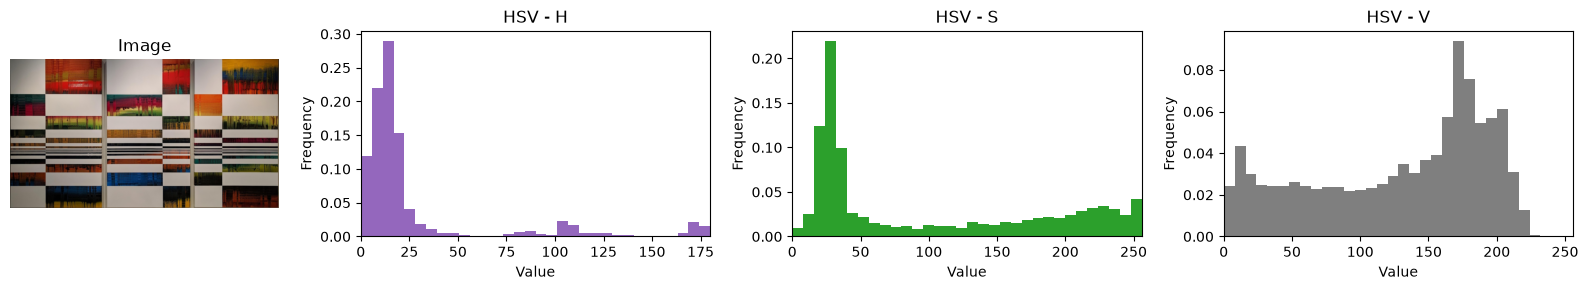

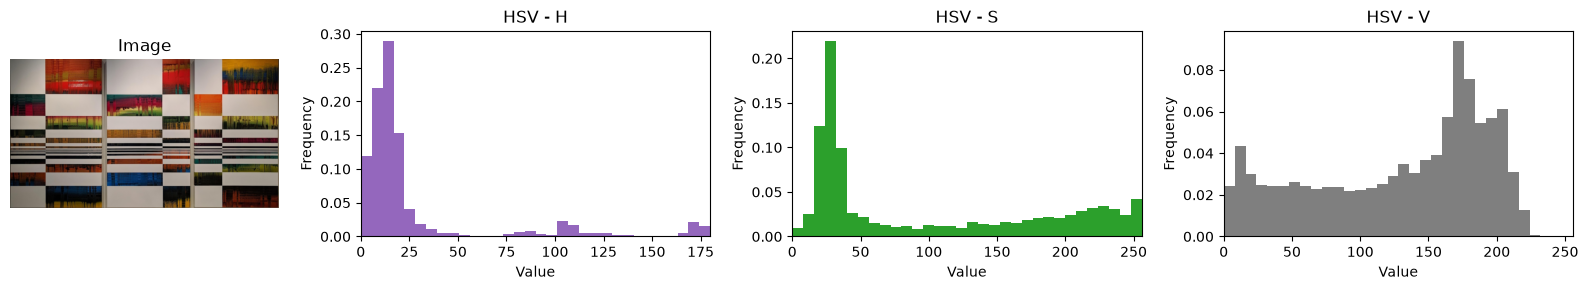

In [15]:
plot_image_histograms(df["image"].iloc[0], color_space="hsv", bins=32)

## Distances

In [ ]:
def compute_distances(query_hist, museum_hists, metric="l1"):
    """
    Compute the distance between one query histogram and all the museum histograms.

    Lower value = more similar, for every metric.

    Parameters:
    query_hist (np.ndarray): Query histogram, shape (3, bins).
    museum_hists (np.ndarray): Museum histograms, shape (n_museum, 3, bins).
    metric (str): One of METRICS.

    Returns:
    np.ndarray: Distances of shape (n_museum,).
    """
    n_channels = query_hist.shape[0]

    # EMD in 1D has a closed form: L1 distance between the cumulative histograms.
    # It is computed per channel (bins are ordered) and summed over channels.
    if metric == "emd":
        cdf_diff = np.cumsum(museum_hists, axis=2) - np.cumsum(query_hist, axis=1)[None]
        return np.abs(cdf_diff).sum(axis=2).sum(axis=1)

    # For the remaining metrics concatenate the channels and renormalize so the
    # vector is a probability distribution (sum = 1).
    q = query_hist.reshape(-1) / n_channels
    m = museum_hists.reshape(len(museum_hists), -1) / n_channels

    if metric == "euclidean":
        return np.sqrt(((q - m) ** 2).sum(axis=1))

    if metric == "l1":
        return np.abs(q - m).sum(axis=1)

    if metric == "chi2":
        # Symmetric chi-square distance (cv2.HISTCMP_CHISQR_ALT, up to a factor)
        return 0.5 * (((q - m) ** 2) / (q + m + EPS)).sum(axis=1)

    if metric == "x2":
        # Classic (asymmetric) chi-square, cv2.HISTCMP_CHISQR: query is the reference
        return (((q - m) ** 2) / (q + EPS)).sum(axis=1)

    if metric == "intersection":
        # Histogram intersection is a similarity in [0, 1] -> turn it into a distance
        return 1.0 - np.minimum(q, m).sum(axis=1)

    if metric in ("bhattacharyya", "hellinger"):
        bc = np.sqrt(q * m).sum(axis=1)  # Bhattacharyya coefficient in [0, 1]
        if metric == "bhattacharyya":
            return -np.log(np.maximum(bc, EPS))      # classic Bhattacharyya distance
        return np.sqrt(np.maximum(1.0 - bc, 0.0))    # Hellinger distance

    raise ValueError(f"Unknown metric '{metric}'. Use one of {METRICS}")


In [ ]:
# --------------------------------------------------------------------------- #
# 4. Retrieval
# --------------------------------------------------------------------------- #
def retrieve_top_k(query_hists, museum_hists, metric="l1", k=10):
    """
    For each query, retrieve the K most similar museum images, ordered by score.

    Parameters:
    query_hists (np.ndarray): Query histograms, shape (n_query, 3, bins).
    museum_hists (np.ndarray): Museum histograms, shape (n_museum, 3, bins).
    metric (str): One of METRICS.
    k (int): Number of images to retrieve per query.

    Returns:
    tuple(np.ndarray, np.ndarray): (indices, distances), both of shape (n_query, k).
    Row i holds the museum indices (and their distances) for query i, best first.
    """
    k = min(k, len(museum_hists))
    indices = np.zeros((len(query_hists), k), dtype=int)
    scores = np.zeros((len(query_hists), k), dtype=np.float64)

    for i, query_hist in enumerate(query_hists):
        distances = compute_distances(query_hist, museum_hists, metric)
        top_k = np.argsort(distances)[:k]
        indices[i] = top_k
        scores[i] = distances[top_k]

    return indices, scores


# --------------------------------------------------------------------------- #
# 5. Evaluation
# --------------------------------------------------------------------------- #
def evaluate_retrieval(query_df, museum_df, indices, label_col="artwork_name"):
    """
    Evaluate retrieval results using the labels of the datasets.

    A retrieved image is correct if it has the same label as the query.
    Queries without label are ignored.

    Parameters:
    query_df (pd.DataFrame): Query dataset.
    museum_df (pd.DataFrame): Museum dataset.
    indices (np.ndarray): Retrieved museum indices, shape (n_query, k).
    label_col (str): Column used as ground truth ('artwork_name' or 'artist').

    Returns:
    dict: hit@1, hit@K (correct image within top-K) and mean precision@K.
    """
    q_labels = query_df[label_col].to_numpy()
    m_labels = museum_df[label_col].to_numpy()

    valid = pd.notna(q_labels)
    if not valid.any():
        raise ValueError(f"No query has a valid '{label_col}' label.")

    k = indices.shape[1]
    matches = (m_labels[indices] == q_labels[:, None])[valid]

    return {
        "hit@1": matches[:, 0].mean(),
        f"hit@{k}": matches.any(axis=1).mean(),
        f"precision@{k}": matches.mean(),
    }


def run_experiments(query_df, museum_df, color_spaces=("hsv", "lab", "ycbcr"),
                    metrics=METRICS, bins=32, k=10, label_col="artwork_name"):
    """
    Run every combination of color space and distance and collect the results.

    Parameters:
    query_df (pd.DataFrame): Query dataset.
    museum_df (pd.DataFrame): Museum dataset.
    color_spaces (iterable): Color spaces to test.
    metrics (iterable): Distances to test.
    bins (int): Number of bins per channel.
    k (int): Number of images to retrieve per query.
    label_col (str): Column used as ground truth.

    Returns:
    pd.DataFrame: One row per (color_space, metric) with the evaluation scores.
    """
    results = []

    for color_space in color_spaces:
        # Histograms depend only on the color space, so compute them once
        query_hists = compute_histograms(query_df, color_space, bins)
        museum_hists = compute_histograms(museum_df, color_space, bins)

        for metric in metrics:
            indices, _ = retrieve_top_k(query_hists, museum_hists, metric, k)
            scores = evaluate_retrieval(query_df, museum_df, indices, label_col)
            results.append({"color_space": color_space, "metric": metric, **scores})

    return pd.DataFrame(results).sort_values(f"precision@{k}", ascending=False).reset_index(drop=True)

In [ ]:
# --------------------------------------------------------------------------- #
# Example usage
# --------------------------------------------------------------------------- #
if __name__ == "__main__":
    museum_df = build_dataset("path/to/museum")
    query_df = build_dataset("path/to/query")

    K = 10

    # --- Retrieval for one configuration -----------------------------------
    museum_hists = compute_histograms(museum_df, color_space="hsv", bins=32)
    query_hists = compute_histograms(query_df, color_space="hsv", bins=32)
    indices, distances = retrieve_top_k(query_hists, museum_hists, metric="hellinger", k=K)

    print("Query 0 ->", query_df["image_path"].iloc[0])
    for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), start=1):
        print(f"  {rank:2d}. {museum_df['image_path'].iloc[idx]}  (distance={dist:.4f})")

    # --- Compare all color spaces x distances ------------------------------
    results = run_experiments(query_df, museum_df, bins=32, k=K)
    print(results.to_string(index=False))

# Visualization

In [ ]:

# --------------------------------------------------------------------------- #
# 6. Visualization
# --------------------------------------------------------------------------- #
# Channel names and plotting colors for each color space
CHANNEL_INFO = {
    "hsv":   (["H", "S", "V"],   ["tab:purple", "tab:green", "tab:gray"]),
    "lab":   (["L", "a", "b"],   ["tab:gray", "tab:red", "tab:blue"]),
    "ycbcr": (["Y", "Cr", "Cb"], ["tab:gray", "tab:red", "tab:blue"]),
}
 
 
def plot_histogram(hist, color_space="hsv", axes=None, title=None, color=None, alpha=1.0, label=None):
    """
    Plot the per-channel 1D histograms of a (3, bins) histogram array.
 
    Parameters:
    hist (np.ndarray): Histogram of shape (3, bins), as returned by compute_histogram_1d.
    color_space (str): Color space the histogram was computed in (sets names and ranges).
    axes (list[plt.Axes] | None): Three axes to draw on. If None, a new figure is created.
    title (str | None): Title of the figure (only used when creating a new figure).
    color (str | None): Force one color for all channels (useful for overlays).
    alpha (float): Bar transparency.
    label (str | None): Legend label.
 
    Returns:
    list[plt.Axes]: The three axes used.
    """
    names, colors = CHANNEL_INFO[color_space]
    ranges = COLOR_SPACES[color_space][1]
    bins = hist.shape[1]
 
    if axes is None:
        fig, axes = plt.subplots(1, 3, figsize=(12, 3))
        if title:
            fig.suptitle(title)
 
    for channel, ax in enumerate(axes):
        low, high = ranges[channel]
        edges = np.linspace(low, high, bins + 1)
        ax.bar(edges[:-1], hist[channel], width=(high - low) / bins, align="edge",
               color=color or colors[channel], alpha=alpha, label=label)
        ax.set_xlim(low, high)
        ax.set_title(f"{color_space.upper()} - {names[channel]}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
 
    return list(axes)
 
 
def plot_image_histograms(image, color_space="hsv", bins=32):
    """
    Show an image next to its 1D histograms in a given color space.
 
    Parameters:
    image (np.ndarray): BGR image, as loaded by cv2.imread.
    color_space (str): One of 'hsv', 'lab', 'ycbcr'.
    bins (int): Number of bins per channel.
 
    Returns:
    plt.Figure: The created figure.
    """
    hist = compute_histogram_1d(image, color_space, bins)
 
    fig, axes = plt.subplots(1, 4, figsize=(16, 3), gridspec_kw={"width_ratios": [1, 1.3, 1.3, 1.3]})
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Image")
    axes[0].axis("off")
 
    plot_histogram(hist, color_space, axes=axes[1:])
    fig.tight_layout()
 
    return fig
 
 
def plot_color_space_comparison(image, bins=32):
    """
    Show the histograms of one image in every color space (one row per color space).
 
    Parameters:
    image (np.ndarray): BGR image, as loaded by cv2.imread.
    bins (int): Number of bins per channel.
 
    Returns:
    plt.Figure: The created figure.
    """
    fig, axes = plt.subplots(len(COLOR_SPACES), 4, figsize=(16, 3 * len(COLOR_SPACES)),
                             gridspec_kw={"width_ratios": [1, 1.3, 1.3, 1.3]})
 
    for row, color_space in enumerate(COLOR_SPACES):
        axes[row, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title("Image")
        axes[row, 0].axis("off")
 
        hist = compute_histogram_1d(image, color_space, bins)
        plot_histogram(hist, color_space, axes=axes[row, 1:])
 
    fig.tight_layout()
 
    return fig
 
 
def plot_histogram_comparison(hist_a, hist_b, color_space="hsv", labels=("Query", "Museum")):
    """
    Overlay two histograms channel by channel, to see why two images are (dis)similar.
 
    Parameters:
    hist_a (np.ndarray): First histogram, shape (3, bins).
    hist_b (np.ndarray): Second histogram, shape (3, bins).
    color_space (str): Color space of the histograms.
    labels (tuple[str, str]): Legend labels.
 
    Returns:
    plt.Figure: The created figure.
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
 
    plot_histogram(hist_a, color_space, axes=axes, color="tab:blue", alpha=0.6, label=labels[0])
    plot_histogram(hist_b, color_space, axes=axes, color="tab:orange", alpha=0.6, label=labels[1])
    axes[0].legend()
    fig.tight_layout()
 
    return fig
 
 
def plot_retrieval_results(query_df, museum_df, query_idx, indices, distances,
                           label_col="artwork_name"):
    """
    Show a query image followed by its retrieved museum images, in rank order.
 
    The title of each retrieved image shows the rank and the distance; it is green
    if the label matches the query label and red otherwise (black if no label).
 
    Parameters:
    query_df (pd.DataFrame): Query dataset.
    museum_df (pd.DataFrame): Museum dataset.
    query_idx (int): Row of the query to display.
    indices (np.ndarray): Retrieved indices, shape (n_query, k), from retrieve_top_k.
    distances (np.ndarray): Retrieved distances, shape (n_query, k), from retrieve_top_k.
    label_col (str): Column used to decide whether a result is correct.
 
    Returns:
    plt.Figure: The created figure.
    """
    k = indices.shape[1]
    fig, axes = plt.subplots(1, k + 1, figsize=(2.6 * (k + 1), 3.2))
 
    axes[0].imshow(cv2.cvtColor(query_df["image"].iloc[query_idx], cv2.COLOR_BGR2RGB))
    axes[0].set_title("Query", fontweight="bold")
    axes[0].axis("off")
 
    query_label = query_df[label_col].iloc[query_idx]
 
    for rank in range(k):
        museum_idx = indices[query_idx, rank]
        museum_label = museum_df[label_col].iloc[museum_idx]
 
        if pd.isna(query_label):
            color = "black"
        else:
            color = "green" if museum_label == query_label else "red"
 
        ax = axes[rank + 1]
        ax.imshow(cv2.cvtColor(museum_df["image"].iloc[museum_idx], cv2.COLOR_BGR2RGB))
        ax.set_title(f"#{rank + 1}  d={distances[query_idx, rank]:.3f}", color=color, fontsize=10)
        ax.axis("off")
 
    fig.tight_layout()
 
    return fig
 
 
def plot_results_heatmap(results, metric_col="precision@10"):
    """
    Plot a color space x distance heatmap of an evaluation metric.
 
    Parameters:
    results (pd.DataFrame): Output of run_experiments.
    metric_col (str): Column of `results` to display (e.g. 'hit@1', 'precision@10').
 
    Returns:
    plt.Figure: The created figure.
    """
    table = results.pivot(index="color_space", columns="metric", values=metric_col)
 
    fig, ax = plt.subplots(figsize=(10, 3))
    im = ax.imshow(table.values, cmap="viridis", aspect="auto")
 
    ax.set_xticks(range(table.shape[1]), table.columns, rotation=30)
    ax.set_yticks(range(table.shape[0]), table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, f"{table.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=9)
 
    ax.set_title(metric_col)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
 
    return fig
 